# UCIHAR Dataset for Human Activity Recognition
- This is very much similar to the [digit_recog_uint](./vsa_digit_recog_uint.ipynb) program as it follows the same feature-level or ID-level encoding.
- Here we investigate similar trends to which encoding scheme provides the highest accuracy.

In [2]:
# Parameters
import os
import sys
import numpy as np

# Path directories
curr_dir = os.getcwd()
lib_path = curr_dir + "/../../lib"
extract_path = curr_dir + "/../../extract_data"
data_path = curr_dir + "/../../data/ucihar"
train_data_path = data_path + "/train"
test_data_path = data_path + "/test"

# Appending other paths for libraries
sys.path.append(lib_path)
sys.path.append(extract_path)

import vsa
import figs
from extract_data_util import download_and_extract, read_data, split_data

## Data Extraction

In [3]:
url = "https://github.com/rgantonio/chronomatica/releases/download/ucihar_dataset_v1.0/chronomatica_ucihar.tar.gz"

download_and_extract(
    url=url,
    out_dir=data_path,
    delete_archive=True,
)

# Set class list
class_list = [0,1,2,3,4,5]

# Read data
train_data = read_data(class_list, train_data_path)
test_data = read_data(class_list, test_data_path)

# Split train and valid data
train_valid_split = 0.75
train_data, valid_data = split_data(train_data, class_list, split_percent=train_valid_split)

Extracting...
Deleted archive: chronomatica_ucihar.tar.gz
Extraction complete!


Splitting data: 100%|██████████| 6/6 [00:00<00:00, 1856.30it/s]


## VSA Model
- In this VSA model, the input features are in `uint8` so similar to MNIST digit recog we use te same representations.
- Here, we have 561 features instead.
- Mathematically we have:

$$ \mathcal{hv}_{\textrm{enc}} = \sum_{i=0}^{N_{\textrm{feat}}=561} \mathcal{hv}_{\textrm{pixel}}[i] \times X[i] $$

- Where $X[i]$ is the feature scalar value.
- We will find out if flattening the result with some binarization matters in here.

In [4]:
class uciharVSA(vsa.ModelVSA):
    def encode(self, item_data):
        # Feature length
        item_len = len(item_data)
        # Threshold for binarization
        threshold = item_len // 2
        # Encode hypervector
        encoded_vec = item_data @ self.ortho_im[0:item_len]
        # Binarization
        if self.binarize_encode:
            encoded_vec = vsa.binarize_hv(encoded_vec, threshold, self.hv_type)
        return encoded_vec

# Training, Retraining, and Testing
- This time we add a switch to collect the accuracies in a list varying the HV dimensions

In [5]:
# Parameters
hv_dim_set = [512, 1024, 2048, 4096, 8192]
hv_dim_set_len = len(hv_dim_set)
accuracy_list = np.zeros(hv_dim_set_len)

In [6]:
for hv_dim in hv_dim_set:
    print(f"Running HV Dimension: {hv_dim}")
    # Create the VSA model with target parameters
    ucihar_model = uciharVSA(
        hv_size = hv_dim,
        class_list = class_list,
    )

    # CHANGE ME FOR EXPERIMENTATION:
    # Add the following to binarize the encoded value
    ucihar_model.binarize_encode = False
    # Add the following to binarize the AM
    ucihar_model.binarize_am = False

    # For debug parameters only
    ucihar_model.tqdm_train_mode = False
    ucihar_model.tqdm_retrain_mode = False
    ucihar_model.tqdm_test_mode = False

    # Train the model
    ucihar_model.train_model(train_data)

    # Retraining the model
    ucihar_model.retrain_model(valid_data)

    # Test the model
    ucihar_model.test_model(test_data)

    # Save accuracy
    accuracy_list[hv_dim_set.index(hv_dim)] = ucihar_model.model_accuracy

for i in range(len(accuracy_list)):
    accuracy_list[i] = accuracy_list[i]*100

accuracy_list

Running HV Dimension: 512
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 1024
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 2048
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 4096
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 8192
Training complete!
Retraining complete!
Testing complete!


array([87.07159824, 86.80013573, 85.98574822, 86.49474041, 86.73227011])

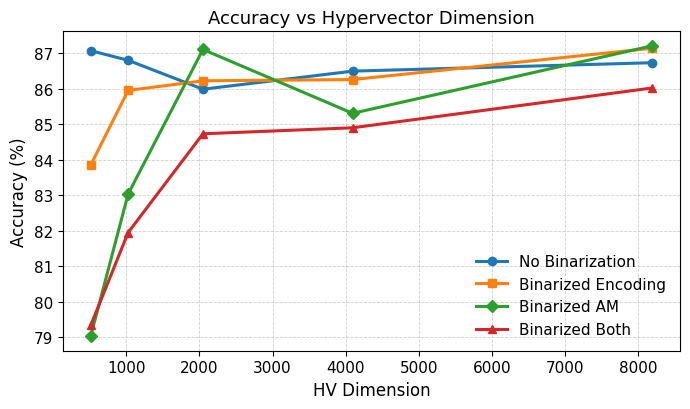

In [8]:
acc = [
    [87.07159824, 86.80013573, 85.98574822, 86.49474041, 86.73227011],
    [83.847981  , 85.95181541, 86.22327791, 86.25721072, 87.13946386],
    [79.02952155, 83.03359348, 87.10553105, 85.30709196, 87.20732949],
    [79.33491686, 81.94774347, 84.73023414, 84.8998982 , 86.01968103],
]

hv_dim = [512, 1024, 2048, 4096, 8192]

legend = ['No Binarization', 'Binarized Encoding', 'Binarized AM', 'Binarized Both']
x_label = 'HV Dimension'
y_label = 'Accuracy (%)'
title = 'Accuracy vs Hypervector Dimension'

figs.multiLinePlot(
    x_data=hv_dim,
    y_data_list=acc,
    legend_list=legend,
    x_label=x_label,
    y_label=y_label,
    title=title,
).plot_fig()

In [ ]:
ucihar_model.print_model_stats()


-----------------
Model Statistics:
-----------------
HV Size: 8192
HV Type: bipolar
Number of Orthogonal IMs: 1024
Number of Continuous IMs: 21
Number of Classes: 6
Binarize Encode: True
Binarize AM: True
Class 0 Accuracy: 89.92%
Class 1 Accuracy: 90.02%
Class 2 Accuracy: 75.00%
Class 3 Accuracy: 72.10%
Class 4 Accuracy: 87.03%
Class 5 Accuracy: 99.26%
Overall Accuracy: 86.02%


## Some Conclusions
- Similar to the DIGIT application, the difference between a binarized encoding and non-binarized one is similar at higher dimensions.
- The benefit of doing low-dimenion is when we use non-binary encoding.
- Consistent to all is that AM **should not be binarized** at all.